___
## EPHYS pre-processing analysis
___

In [112]:
# Load modules and data
import statsmodels.api as sm
from sklearn.linear_model import LogisticRegression

#Import all needed libraries
from matplotlib.lines import Line2D
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.patches as mpatches
from statannot import add_stat_annotation
import itertools
from scipy import stats
from datahandler import Utils
from ast import literal_eval
from glob import glob
from open_ephys.analysis import Session
import pyopenephys
import Openephys

from neo.core import SpikeTrain
from quantities import ms, s, Hz
from elephant.statistics import time_histogram, instantaneous_rate, fanofactor, mean_firing_rate
from elephant.kernels import GaussianKernel
import warnings

In [54]:
def ApplyChannelMap(Data, ChannelMap):
    print('Retrieving channels according to ChannelMap... ', end='')
    for R, Rec in Data.items():
        if Rec.shape[1] < len(ChannelMap) or max(ChannelMap) > Rec.shape[1]-1:
            print('')
            print('Not enough channels in data to apply channel map. Skipping...')
            continue

        Data[R] = Data[R][:,ChannelMap]

    return(Data)

def BitsToVolts(Data, ChInfo, Unit):
    print('Converting to uV... ', end='')
    Data = {R: Rec.astype('float32') for R, Rec in Data.items()}

    if Unit.lower() == 'uv': U = 1
    elif Unit.lower() == 'mv': U = 10**-3

    for R in Data.keys():
        for C in range(len(ChInfo)):
            Data[R][:,C] = Data[R][:,C] * ChInfo[C]['bit_volts'] * U
            if 'ADC' in ChInfo[C]['channel_name']: Data[R][:,C] *= 10**6

    return(Data)

def Load(Folder, Processor=None, Experiment=None, Recording=None, Unit='uV', ChannelMap=[]):
    Files = sorted(glob(Folder+'/**/*.dat', recursive=True))
    InfoFiles = sorted(glob(Folder+'/*/*/structure.oebin'))

    Data, Rate = {}, {}
    for F,File in enumerate(Files):
        File = File.replace('\\', '/') # Replace windows file delims
        Exp, Rec, _, Proc = File.split('/')[-5:-1]
        Exp = str(int(Exp[10:])-1)
        Rec = str(int(Rec[9:])-1)
        Proc = Proc.split('.')[0].split('-')[-1]
        if '_' in Proc: Proc = Proc.split('_')[0]

        if Proc not in Data.keys(): Data[Proc], Rate[Proc] = {}, {}

        if Experiment:
            if int(Exp) != Experiment-1: continue

        if Recording:
            if int(Rec) != Recording-1: continue

        if Processor:
            if Proc != Processor: continue

        print('Loading recording', int(Rec)+1, '...')
        if Exp not in Data[Proc]: Data[Proc][Exp] = {}
        Data[Proc][Exp][Rec] = np.memmap(File, dtype='int16', mode='c')


        Info = literal_eval(open(InfoFiles[F]).read())
        ProcIndex = [Info['continuous'].index(_) for _ in Info['continuous']
                     if str(_['source_processor_id']) == Proc][0] # Changed to source_processor_id from recorded_processor_id

        ChNo = Info['continuous'][ProcIndex]['num_channels']
        if Data[Proc][Exp][Rec].shape[0]%ChNo:
            print('Rec', Rec, 'is broken')
            del(Data[Proc][Exp][Rec])
            continue

        SamplesPerCh = Data[Proc][Exp][Rec].shape[0]//ChNo
        Data[Proc][Exp][Rec] = Data[Proc][Exp][Rec].reshape((SamplesPerCh, ChNo))
        Rate[Proc][Exp] = Info['continuous'][ProcIndex]['sample_rate']

    for Proc in Data.keys():
        for Exp in Data[Proc].keys():
            if Unit.lower() in ['uv', 'mv']:
                ChInfo = Info['continuous'][ProcIndex]['channels']
                Data[Proc][Exp] = BitsToVolts(Data[Proc][Exp], ChInfo, Unit)

            if ChannelMap: Data[Proc][Exp] = ApplyChannelMap(Data[Proc][Exp], ChannelMap)

    print('Done.')

    return(Data, Rate)

In [55]:
# constants
NUM_HEADER_BYTES = 1024
SAMPLES_PER_RECORD = 1024
BYTES_PER_SAMPLE = 2
RECORD_SIZE = 4 + 8 + SAMPLES_PER_RECORD * BYTES_PER_SAMPLE + 10 # size of each continuous record in bytes
RECORD_MARKER = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 255])

# constants for pre-allocating matrices:
MAX_NUMBER_OF_SPIKES = int(1e6)
MAX_NUMBER_OF_RECORDS = int(1e6)
MAX_NUMBER_OF_EVENTS = int(1e6)

def loadContinuous(filepath, dtype = float):

    assert dtype in (float, np.int16), \
      'Invalid data type specified for loadContinous, valid types are float and np.int16'

    print("Loading continuous data...")

    ch = { }

    #read in the data
    f = open(filepath,'rb')

    fileLength = os.fstat(f.fileno()).st_size

    # calculate number of samples
    recordBytes = fileLength - NUM_HEADER_BYTES
    
    # if  recordBytes % RECORD_SIZE != 0:
    #     raise Exception("File size is not consistent with a continuous file: may be corrupt")
    nrec = recordBytes // RECORD_SIZE
    nsamp = nrec * SAMPLES_PER_RECORD
    # pre-allocate samples
    samples = np.zeros(nsamp, dtype)
    timestamps = np.zeros(nrec)
    recordingNumbers = np.zeros(nrec)
    indices = np.arange(0, nsamp + 1, SAMPLES_PER_RECORD, np.dtype(np.int64))

    header = readHeader(f)

    recIndices = np.arange(0, nrec)

    for recordNumber in recIndices:

        timestamps[recordNumber] = np.fromfile(f,np.dtype('<i8'),1) # little-endian 64-bit signed integer
        N = np.fromfile(f,np.dtype('<u2'),1)[0] # little-endian 16-bit unsigned integer

        #print index

        if N != SAMPLES_PER_RECORD:
            raise Exception('Found corrupted record in block ' + str(recordNumber))

        recordingNumbers[recordNumber] = (np.fromfile(f,np.dtype('>u2'),1)) # big-endian 16-bit unsigned integer

        if dtype == float: # Convert data to float array and convert bits to voltage.
            data = np.fromfile(f,np.dtype('>i2'),N) * float(header['bitVolts']) # big-endian 16-bit signed integer, multiplied by bitVolts
        else:  # Keep data in signed 16 bit integer format.
            data = np.fromfile(f,np.dtype('>i2'),N)  # big-endian 16-bit signed integer
        samples[indices[recordNumber]:indices[recordNumber+1]] = data

        marker = f.read(10) # dump

    #print recordNumber
    #print index

    ch['header'] = header
    ch['timestamps'] = timestamps
    ch['data'] = samples  # OR use downsample(samples,1), to save space
    ch['recordingNumber'] = recordingNumbers
    f.close()
    return ch

In [56]:
# Importing the data from a session
path = 'C:/Users/Tiffany/Desktop/E18_2022-04-28_15-46-18/'
os.getcwd() 
os.chdir(path)

______
***Processing for one session***
_____________

First we will recovr the spikes of a session

In [5]:
# Load spike sorted data
spike_times= np.load('spike_times.npy') # Times of the spikes, array of lists
spike_clusters= np.load('spike_clusters.npy') # cluster number of each of the spikes, same length as before
df_labels = pd.read_csv("cluster_group.tsv",sep='\t') # Cluster labels (good, noise, mua) for the previous two arrays

In [6]:
# Transforms array of lists into array of ints
spike_times_df = [item for sublist in spike_times for item in sublist]

In [7]:
# Put the data in a single dataframe, one colum spikes, one colum clusters
s1 = pd.Series(spike_times_df, name='times')
s2 = pd.Series(spike_clusters, name='cluster_id')
df_temp = pd.concat([s1, s2], axis=1)

In [8]:
# Merge with cluster labels, use cluster ID to associate each one
df = pd.merge(df_temp,df_labels, on=['cluster_id'])

In [12]:
print('Number of good: ' + str(len(df.groupby('group')['cluster_id'].unique()['good'])) + ', Number of mua: ' + str(len(df.groupby('group')['cluster_id'].unique()['mua'])))

Number of good: 25, Number of mua: 2


In [13]:
# Select only clusters labelled good or mua, which are presumably single units or mua
df = df.loc[(df.group == 'good')|(df.group == 'mua')]

In [14]:
# Transform the values per session to seconds. This takes into account the framerate of the recordings, 30000Hz for virtually all the sessions. 
df['fixed_times'] = (df.times/30000)
print(min(df['fixed_times']),max(df['fixed_times']))

0.017733333333333334 867.1182333333334


C:\Users\Tiffany\Anaconda3\envs\envr\lib\site-packages\seaborn\_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


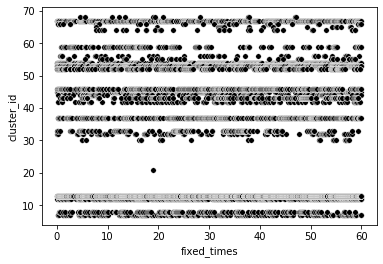

In [15]:
# Plot the first minute to have an impression of how it looks like
sns.scatterplot('fixed_times','cluster_id', data = df.loc[(df['fixed_times']<60)&(df.group=='good')],s=30,color='black')

In [16]:
# Save spikes
os.getcwd() 
os.chdir(path)
df.to_csv(path+'/spike.csv')

___
***Recover the ttls of delays from the dat files.***

In [57]:
# Use when the binary used
df_ttl = pd.DataFrame()
session = Session(path)

In [ ]:
# Use when not saved as binary by default
session = Openephys.loadContinuous(path+'/100_36.continuous')

samples = session['data']
timestamps = session['timestamps']

# Put the data in a single dataframe
s1 = pd.Series(samples, name='samples')
s2 = pd.Series(timestamps, name='timestamps')

df_ttl = pd.concat([s1, s2], axis=1)
df_ttl.samples = (session['data']/0.000152588)

In [59]:
try:
    print('Old Gui version')
    # Replace recordings or continuous index depending on the number of recordings (play and stop recording) in one session
    samples = session.recordings[0].continuous[0].samples[:,-8]
    timestamps = session.recordings[0].continuous[0].timestamps

    # samples = session.recordings[0].continuous[0].samples[:,-7]
    
except:
    print('New version')
    # Way to recover the data with recording node (Gui >0.5)
    session.recordnodes[0].recordings[0].continuous[0].metadata
    samples = session.recordnodes[0].recordings[0].continuous[0].samples[:,-8] # Delay channel. 
    timestamps = session.recordnodes[0].recordings[0].continuous[0].timestamps

# Put the data in a single dataframe
s1 = pd.Series(samples, name='samples')
s2 = pd.Series(timestamps, name='timestamps')

df_ttl = pd.concat([s1, s2], axis=1)

Old Gui version


In [60]:
# Transform the analog channel to boolean. 
df_ttl.loc[df_ttl['samples'] >=3000, 'ttl'] = 1
df_ttl.loc[df_ttl['samples'] <3000, 'ttl'] = 0

# Look for the places where there is a change and it goes from 0 to 1. 1 for on delay and -1 for off delay
df_ttl['diff'] = df_ttl.ttl.diff()
df_ttl['diff'].unique()

array([nan,  0.,  1., -1.])

On is a 1 and -1 is an off of the delay period

In [61]:
# Recover the first timestamp of the session. This is important because it is not 0 but when the recording was started. 
initial = df_ttl.timestamps.iloc[0]

In [62]:
# Substract the first timestamp and divide by sampling frequency
df_ttl.timestamps = (df_ttl.timestamps - initial)/30000

In [63]:
# Remove the rest of the values that does not have a change. 
df_ttl = df_ttl.loc[(df_ttl['diff'] == 1)|(df_ttl['diff'] == -1)]

In [64]:
df_ttl['timestamps_corr'] = df_ttl.index

In [65]:
# Create a new colum with the delay duration
df_ttl['delay'] = np.around(df_ttl.loc[(df_ttl['diff'] == 1)|(df_ttl['diff'] == -1)]['timestamps'].diff(),2)

In [66]:
# Check that we recover all the delays that were used. 
df_ttl.delay.unique()

array([ nan, 3.  , 7.21, 0.2 , 9.19, 7.2 , 9.8 , 9.18, 1.  , 9.34, 7.47,
       9.36, 7.51, 7.37, 7.44, 9.37, 9.45, 7.41, 9.33, 7.39, 9.38, 9.41,
       9.49, 7.36, 7.48, 9.42, 9.43, 9.39])

In [67]:
# Save the data in a new csv. 
os.getcwd() 
os.chdir(path)
df_ttl.to_csv(path+'/timestamps.csv')

In [68]:
# Remove all the colums which don't show the right delay lengths. 
df_ttl = df_ttl.loc[(df_ttl['delay'] == 1) | (df_ttl['delay'] == 10)| (df_ttl['delay'] == 3.00)| (df_ttl['delay'] == 0.2)]

In [69]:
df_ttl.delay.unique()

array([3. , 0.2, 1. ])

In [70]:
len(df_ttl)

52

___________
**Recover the behavior for that session**

In [71]:
## Recover the session to match the delay sequence

path2 = 'C:/Users/Tiffany/Google Drive/WORKING_MEMORY/EXPERIMENTS/ELECTROPHYSIOLOGY/EphysB2/globals'
os.getcwd() 
os.chdir(path2)

df_trials = pd.read_csv(path2 + '/global_trials.csv', sep=';')
df_params = pd.read_csv(path2 + '/global_params.csv', sep=';')
df_behavior = pd.merge(df_params,df_trials, on=['session','subject_name'])

#Rename some of the variables for a global consensus.
df_behavior = df_behavior.rename(columns={'subject_name': 'subject','hithistory': 'hit', 'probabilities': 'prob', 'validhistory': 'valids'})

C:\Users\Tiffany\Anaconda3\envs\envr\lib\site-packages\IPython\core\interactiveshell.py:3051: DtypeWarning: Columns (6,27,28,29,30,41,42,45,46,49,50,55,56,72,73) have mixed types.Specify dtype option on import or set low_memory=False.
  interactivity=interactivity, compiler=compiler, result=result)


In [72]:
# Select only the session and animal that we need
df_behavior = df_behavior.loc[(df_behavior.day == '2022-04-28')&(df_behavior.subject == 'E18')]

In [73]:
df_behavior.head()

,session_name,stage_number,subject,day,time,box,date_x,task,fixation,timeout,...,User_end,L_e,C_e,C_s,L_s,date_y,Delay_start,Delay_end,ITI_incorrect_start,ITI_incorrect_end
150718,E18_StageTraining_Ephys_V5_20220428-155150,3,E18,2022-04-28,15:51:50,Ephys,20220428-155150,StageTraining_Ephys_V5,0.5,2.0,...,NaN,NaN,NaN,NaN,NaN,20220428-155150,NaN,NaN,3.0491,7.0491
150719,E18_StageTraining_Ephys_V5_20220428-155150,3,E18,2022-04-28,15:51:50,Ephys,20220428-155150,StageTraining_Ephys_V5,0.5,2.0,...,NaN,"4.1705000000000005,4.1761,4.1986,4.2377,4.2647",NaN,NaN,"4.1582,4.1732000000000005,4.1935,4.23150000000...",20220428-155150,0.9412,3.9412,NaN,NaN
150720,E18_StageTraining_Ephys_V5_20220428-155150,3,E18,2022-04-28,15:51:50,Ephys,20220428-155150,StageTraining_Ephys_V5,0.5,2.0,...,NaN,NaN,NaN,NaN,NaN,20220428-155150,0.9417,1.1417,3.3797,7.3797
150721,E18_StageTraining_Ephys_V5_20220428-155150,3,E18,2022-04-28,15:51:50,Ephys,20220428-155150,StageTraining_Ephys_V5,0.5,2.0,...,NaN,NaN,NaN,NaN,NaN,20220428-155150,0.9417,1.1417,3.3797,7.3797
150722,E18_StageTraining_Ephys_V5_20220428-155150,3,E18,2022-04-28,15:51:50,Ephys,20220428-155150,StageTraining_Ephys_V5,0.5,2.0,...,NaN,"1.3729,1.3841",NaN,NaN,"1.3562,1.3769",20220428-155150,0.9412,1.1412,NaN,NaN


In [74]:
df_behavior['hit']= df_behavior['hit'].astype(float)

# Compute vector of answers
vector_answer_dev = np.logical_not(np.logical_xor(df_behavior['reward_side'], df_behavior['hit'].astype(int)))
vector_answer = np.where(vector_answer_dev==False, 0, 1)
df_behavior['vector_answer'] = vector_answer
df_behavior['previous_vector_answer'] = df_behavior['vector_answer'].shift(1)
df_behavior['previous_valids'] = df_behavior['valids'].shift(1)

In [75]:
df_behavior = Utils.convert_strings_to_lists(df_behavior, ['L_s', 'C_s','C_e','L_e'])

In [76]:
# Add a colum for first lick
df_temp =[]
for i in range(len(df_behavior)):
    if df_behavior.C_s.iloc[i][0] > df_behavior.L_s.iloc[i][0] or np.isnan(df_behavior.C_s.iloc[i][0]):
        df_temp.append(df_behavior.L_s.iloc[i][0])
    elif df_behavior.C_s.iloc[i][0] < df_behavior.L_s.iloc[i][0] or np.isnan(df_behavior.L_s.iloc[i][0]):
        df_temp.append(df_behavior.C_s.iloc[i][0])
    else:
        df_temp.append(np.nan)
        
df_behavior['lick'] = np.array(df_temp)

In [ ]:
df_behavior.loc[:,['L_s','C_s','lick','ResponseWindow_start','Delay_end']].head(10)

In [79]:
def repeat(row):
    if row['trials'] != 0:
        if row['vector_answer'] == row['previous_vector_answer'] and row['valids'] == True:
            return 1
        elif row['valids'] == True and row['previous_valids'] == True:
            return 0
        else:
            return np.nan
    else:
        return np.nan

In [80]:
df_behavior = df_behavior[df_behavior['Delay_start'].notna()] # Remove the trials with nans in the delay onset (first trial)

**Test if the trials recovered with the TTL match the sequence of delays**

In [81]:
np.array_equal(df_behavior.delay_times,df_ttl.delay)

True

In [82]:
len(df_behavior.delay_times)

52

In [83]:
len(df_ttl.delay)

52

**Use the saved dataframes that contain all the information**

In [84]:
# Recover previous timestamps session
df_ttl = pd.read_csv(path + '/timestamps.csv', sep=',', index_col=0)
df = pd.read_csv(path + '/spike.csv', sep=',', index_col=0)

In [85]:
df_ttl.loc[df_ttl['ttl'] == 1, 'Delay_ON'] = df_ttl['timestamps'] # Mark onset of delays
df_ttl.loc[df_ttl['ttl'] == 0, 'Delay_OFF_next'] = df_ttl['timestamps'] # Mark offset of delay

In [86]:
# Create new colum with delay offset to measure the delay duration and then remove it
df_ttl['Delay_OFF'] = df_ttl['Delay_OFF_next'].shift(-1)
df_ttl['Delay_length'] = df_ttl['Delay_OFF']  - df_ttl['Delay_ON'] 
df_ttl.drop('Delay_OFF_next',axis='columns', inplace=True)

In [87]:
df_ttl = df_ttl[df_ttl['Delay_ON'].notna()] # Remove the trials with nans

In [88]:
# Prepare a column with trial index. start in 1 because trial 0 doesn't have a delay and is not there. 
df_ttl['trial'] = np.arange(len(df_ttl))+1
df_behavior['trials'] = np.arange(len(df_behavior))+1

In [89]:
# Merge with cluster labels, use trial to associate each one
df_behavior.rename(columns= {'trials': 'trial'},inplace=True)
df2_behavior = pd.merge(df_behavior,df_ttl, on=['trial'])

In [90]:
df_final = pd.DataFrame()
# We now have the moment of the onset of the delay and what it corresponds in the behavioral session. If we substract this we can get the start 
# for every session. Then, we will use the START for everything else. 

df2_behavior['START'] = df2_behavior['Delay_ON']-df2_behavior['Delay_start']
df_final['START'] = df2_behavior['Delay_ON']-df2_behavior['Delay_start']
df_final['Delay_ON'] = df2_behavior['Delay_ON']
df_final['Delay_OFF'] = df2_behavior['Delay_OFF']

In [92]:
df_final['Stimulus_ON'] = df2_behavior['START'] + df2_behavior['StimulusDuration_start'] + 0.05 # Mp3 has a 50ms time with no sound
# df_final['Lick_ON'] = df2_behavior['START'] + df2_behavior['lick']
df2_behavior['END'] = df2_behavior['START']+ df2_behavior['Motor_out_end']+0.006 # That what it takes for Bpod to load next trial
df_final['Motor_OUT'] = df2_behavior.END  - 2
df_final['END'] = df2_behavior.END

In [93]:
df_final['vector_answer'] = df2_behavior['vector_answer']
df_final['reward_side'] = df2_behavior['reward_side']
df_final['hit'] = df2_behavior['hit']
# df_final['repeat_choice'] = df2_behavior['repeat_choice']
df_final['miss'] = df2_behavior['misshistory']
df_final['trial'] = df2_behavior['trial']
df_final['delay'] = np.around(df2_behavior['Delay_OFF']-df2_behavior['Delay_ON'],2)

In [ ]:
df_final.tail(10)

In [95]:
# Save the data in a new csv (another way of saving it)
os.getcwd() 
os.chdir(path)
df_final.to_csv(path+'timestamps_only.csv')

In [96]:
# With this we will assign the spikes to the corresponding trial
df['trial'] = 0
for i,rows in df_final.iterrows():
    # create a list of our conditions
    conditions = [(df.fixed_times > df_final['START'].iloc[i])&(df.fixed_times <= df_final['END'].iloc[i]),
                 (df.fixed_times < df_final['START'].iloc[i])]

    # create a list of the values we want to assign for each condition
    values = [df_final['trial'].iloc[i],df['trial']]

    # create a new column and use np.select to assign values to it using our lists as arguments
    df['trial'] = np.select(conditions, values)

In [97]:
df.trial.unique() # Check that we have the expected amount of trials

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51], dtype=int64)

In [98]:
# Save the data in a new csv (this is just another way to save the data)
os.getcwd() 
os.chdir(path)
df.to_csv(path+'spikes_trial.csv')

In [99]:
# Check one trial to confirm that it has a standard duration
print(df_final[df_final['trial'] ==1]['START'].iloc[0],df_final[df_final['trial'] ==1]['END'].iloc[0])

343.274 353.4761


In [100]:
df_final[df_final['trial'] ==1]['delay'].iloc[0]

3.0

In [101]:
# Merge with cluster labels, use cluster ID to associate each one
df3 = pd.merge(df,df_final, on=['trial'])

In [91]:
df3 = df3[df3.trial != df3.trial.unique()[-1]]

In [225]:
# df3['a_Stimulus_ON'] = df3['fixed_times'] - df3['Stimulus_ON']
# df3['a_Response_ON'] = df3['fixed_times'] - df3['Response_ON']
# df3['a_Lick_ON'] = df3['fixed_times'] - df3['Lick_ON']
# df3['a_Delay_OFF'] = df3['fixed_times'] - df3['Delay_OFF']

# min(df3.a_Delay_OFF)

In [226]:
# df3 = df3.drop(['times','group','accuracy','accuracy_high','accuracy_left','accuracy_low','accuracy_medium','accuracy_right','box','catch','date_x','date_y','day','delay_h','delay_l','delay_m','correct_trials','index','drug','fixation','invalid_trials','delay_progression_value'], axis=1)

In [105]:
df3.head()

,cluster_id,group,fixed_times,trial,START,Delay_ON,Delay_OFF,Stimulus_ON,Motor_OUT,END,vector_answer,reward_side,hit,miss,delay
0,54,good,343.330733,1,343.274,344.2152,347.215233,343.8352,351.4761,353.4761,0,0,1.0,False,3.0
1,54,good,343.626633,1,343.274,344.2152,347.215233,343.8352,351.4761,353.4761,0,0,1.0,False,3.0
2,54,good,343.684133,1,343.274,344.2152,347.215233,343.8352,351.4761,353.4761,0,0,1.0,False,3.0
3,54,good,343.910433,1,343.274,344.2152,347.215233,343.8352,351.4761,353.4761,0,0,1.0,False,3.0
4,54,good,344.446300,1,343.274,344.2152,347.215233,343.8352,351.4761,353.4761,0,0,1.0,False,3.0


In [104]:
df3 = df3.drop(['times'], axis=1)

In [95]:
# Merge with cluster labels, use cluster ID to associate each one
# df2.rename(columns= {'trials': 'trial'},inplace=True)
# df2 = pd.merge(df2,df_behavior[['lick','trial','vector_answer','reward_side','hit','misshistory','repeat_choice']], on=['trial'])

In [106]:
# Save the data in a new csv. 
os.getcwd() 
os.chdir(path)
df3.to_csv(path+'data.csv')

_________________________________________

## Plot some rasters!!



In [114]:
def convolve(nx,  df):
    '''
    nx = already selected cluster
    df = dataframe from the session with all trials
    '''
    errors_=[] ##indexes and neurons without enough spikes to make a spiketrain
    frames=[]
    
    # Iterate for each trial in that session
    for T in df.trial.unique():

        # Take the spike times for that trial
        nxt = nx.loc[nx['trial']==T]['fixed_times']

        # !!!! IMPORTANT use the main df that has all the trials. If you use the filtered nx, some trials may not appear if they were no spikes there. 
        dft = df.loc[df['trial']==T]
        try: 
            ############################################################ Get the times of the spikes
            times_spikes = nxt
            times_spikes = times_spikes*1000 #transform to ms

            ############################################################ Set the strat and end time of the train
            stop_time =  (dft.END.unique()[0])*1000*ms ## End of the trial in ms
            start_time = dft.START.unique()[0]*1000*ms ## Start of the trial in ms    

            ############################################################ Spiketrain
            spiketrain = SpikeTrain(times_spikes, units=ms, t_stop=stop_time, t_start=start_time) 

            ############################################################ Convoluted firing rate
            histogram_rate = time_histogram([spiketrain], 2*ms, output='rate')
            gaus_rate = instantaneous_rate(spiketrain, sampling_period=2*ms, kernel=GaussianKernel(30*ms)) #s.d of Suzuki & Gottlieb 
            times_ = gaus_rate.times.rescale(ms)
            firing = gaus_rate.rescale(histogram_rate.dimensionality).magnitude.flatten()
            
            ############################################################ Dataframe 
            ############################################################ Dataframe 
            df_trial = pd.DataFrame({'times':times_, 'firing':firing}) #dataframe con times y firing
            df_trial['trial']=T
    #         df_trial['Delay_ON']= nxt.Delay_ON.unique()[0]*1000
            df_trial['Delay_OFF']= dft.Delay_OFF.unique()[0]*1000
            df_trial['Stimulus_ON']= dft.Stimulus_ON.unique()[0]*1000
#             df_trial['Lick_ON']= dft.Lick_ON.unique()[0]*1000
    #         df_trial['Response_ON']= dft.Response_ON.unique()[0]*1000
    #         df_trial['START']= nxt.START.unique()[0]*1000
    #         df_trial['END']= nxt.END.unique()[0]*1000
            df_trial['delay']=dft.delay.unique()[0]
            df_trial['vector_answer']=dft.vector_answer.unique()[0]
            df_trial['reward_side']=dft.reward_side.unique()[0]
            df_trial['miss']=dft.miss.unique()[0]
            df_trial['hit']=dft.hit.unique()[0]

            frames.append(df_trial)
        except ValueError:
            errors_.append([N,T])
            print (N, T)
    ####
    neuron = pd.concat(frames)
    return neuron

In [122]:
def single_plot(pdf, N, neuron, df, outcome = False, stimulus = False, choice = False, view=True, response='Lick_ON'): 
    '''
    This function is used to plot the PSTH for several conditions.
    pdf = pdf file opened 
    N = number neuron being analyzed (int)
    neuron = convolved dataframe for the firing rate of such neuron (df)
    df = original dataframe of spikes, to plot the raster plot (df)
    '''
    fig, ax = plt.subplots(3,2,figsize=(20,10))
    if outcome == True:
        fig.suptitle ('Divided by correct and incorrect response without delays of 0s')
        variable = 'hit'
        colors = ['crimson','darkgreen']
        labels = ['Incorrect response','Correct response']
        
    if stimulus == True:
        fig.suptitle ('Divided by left and right stimulus without delays of 0s')
        variable = 'reward_side'
        colors = [COLORLEFT, COLORRIGHT]
        labels = ['Left stimulus','Right stimulus']
        
    if choice == True:
        fig.suptitle ('Divided by left and right response without delays of 0s')
        variable = 'vector_answer'
        colors = [COLORLEFT, COLORRIGHT]
        labels = ['Left response','Right response']
        
    if response == 'Lick_ON':
        df['a_Response_Lick'] = df['Response_ON'] - df['Lick_ON']
        onset_motor = df.a_Response_Lick.mean()
        offset_motor = 0

#     print('Onset:' + str(onset_motor))
#     print('Offset:' + str(offset_motor))

# ----- Do Left plot with alignment to stimulus
    align = 'Stimulus_ON'
    cue_on=0
    cue_off=0.43
    start=-0.5
    stop=1.4           
#     print(align)

    # Align the data to the targeted align
    neuron['time_centered'] = neuron['times'] - neuron[align]
    neuron['time_centered'] = np.round(neuron.time_centered/1000, 2) #### estos es importante!!
    neuron['firing_'] = neuron['firing']*1000

    df_results = pd.DataFrame(dtype=float)
    df_results['firing'] = neuron.loc[(neuron.time_centered >= start)&(neuron.time_centered <= stop)].groupby(['time_centered',variable])['firing_'].mean()
    df_results['error'] = neuron.loc[(neuron.time_centered >= start)&(neuron.time_centered <= stop)].groupby(['time_centered',variable])['firing_'].std()
    df_results.reset_index(inplace=True)

    for condition,color,name in zip([0,1],colors,labels):
        y_mean= df_results[df_results[variable]==condition].firing
        error = df_results[df_results[variable]==condition].error
        lower = y_mean - error/2
        upper = y_mean + error/2
        x=df_results[df_results[variable]==condition].time_centered

        ax[2][0].plot(x, y_mean, label=name,color=color)
        ax[2][0].plot(x, lower, color=color, alpha=0.1)
        ax[2][0].plot(x, upper, color=color, alpha=0.1)
        ax[2][0].fill_between(x, lower, upper, alpha=0.2, color=color)

    limit_y= max(df_results[(df_results.time_centered < 1)].firing + df_results[(df_results.time_centered < 1)].error/2)

    ax[2][0].set_xlim(start,stop)  
    ax[1][0].set_xlim(start,stop)  
    ax[0][0].set_xlim(start,stop)  
    
    SpikesRight = df.loc[(df.delay != 0.2)&(df.delay != 0.1)&(df[variable] == 1)&(df.miss == 0)]
    SpikesLeft = df.loc[(df.delay != 0.2)&(df.delay != 0.1)&(df[variable] == 0)&(df.miss == 0)]  
    
    SpikesLeft = SpikesLeft.loc[(df.cluster_id == N)]
    SpikesRight = SpikesRight.loc[(df.cluster_id == N)]
    
    SpikesLeft['a_'+align] = SpikesLeft['fixed_times'] - SpikesLeft[align]
    SpikesRight['a_'+align] = SpikesRight['fixed_times'] - SpikesRight[align]
    
    trial=1
    j=1
    spikes = []
    trial_repeat = []
    for i in range(len(SpikesRight)):
        # Plot for licks for left trials
        if SpikesRight.trial.iloc[i] != trial:
            ax[0][0].plot(spikes,trial_repeat, '|', markersize=5, color=colors[1], zorder=1)
            spikes = []
            trial_repeat = []
            trial = SpikesRight.trial.iloc[i]
            j+=1
        if SpikesRight['a_'+align].iloc[i] > start and SpikesRight['a_'+align].iloc[i] < stop:
            spikes.append(SpikesRight['a_'+align].iloc[i])
            trial_repeat.append(j)
        else:
            continue
    y = np.arange(0,j,0.1)
    ax[0][0].fill_betweenx(y, cue_on,cue_off, color='grey', alpha=.2)
    ax[0][0].set_ylim(0,j)
    
    trial=1
    j=1
    spikes = []
    trial_repeat = []
    for i in range(len(SpikesLeft)):
        # Plot for licks for left trials
        if SpikesLeft.trial.iloc[i] != trial:
            ax[1][0].plot(spikes,trial_repeat, '|', markersize=5, color=colors[0], zorder=1)
            spikes = []
            trial_repeat = []
            trial = SpikesLeft.trial.iloc[i]
            j+=1
        if SpikesLeft['a_'+align].iloc[i] > start and SpikesLeft['a_'+align].iloc[i] < stop:
            spikes.append(SpikesLeft['a_'+align].iloc[i])
            trial_repeat.append(j)
        else:
            continue
    ax[1][0].set_ylim(0,j)
    y = np.arange(0,j,0.1)
    ax[1][0].fill_betweenx(y, cue_on,cue_off, color='grey', alpha=.2)

    ax[0][0].set_ylabel('Trials (n)')
    ax[1][0].set_ylabel('Trials (n)')

    ax[0][0].locator_params(axis='y', nbins=3)
    ax[1][0].locator_params(axis='y', nbins=3)

    ax[0][0].locator_params(axis='x', nbins=4)
    ax[1][0].locator_params(axis='x', nbins=4)

    # axis labels and legend
    ax[2][0].set_xlabel('Time (s) from stimulus onset')
    ax[2][0].set_ylabel('Firing rate (1/s)')

# ----- Do Right plot with alignment to response            
    align = response
    cue_on=-0.05
    cue_off=0.05
    start=-1
    stop=2
#     print('Delay_OFF')
    # Align the data to the targeted align
    neuron['time_centered'] = neuron['times'] - neuron[align]
    neuron['time_centered'] = np.round(neuron.time_centered/1000, 2) #### estos es importante!!
    neuron['firing_'] = neuron['firing']*1000

    df_results = pd.DataFrame(dtype=float)
    df_results['firing'] = neuron.loc[(neuron.time_centered >= start)&(neuron.time_centered <= stop)].groupby(['time_centered',variable])['firing_'].mean()
    df_results['error'] = neuron.loc[(neuron.time_centered >= start)&(neuron.time_centered <= stop)].groupby(['time_centered',variable])['firing_'].std()
    df_results.reset_index(inplace=True)

    for condition,color,name in zip([0,1],colors,labels):
        y_mean= df_results[df_results[variable]==condition].firing
        error = df_results[df_results[variable]==condition].error
        lower = y_mean - error/2
        upper = y_mean + error/2
        x=df_results[df_results[variable]==condition].time_centered

        ax[2][1].plot(x, y_mean, label=name,color=color)
        ax[2][1].plot(x, lower, color=color, alpha=0.1)
        ax[2][1].plot(x, upper, color=color, alpha=0.1)
        ax[2][1].fill_between(x, lower, upper, alpha=0.2, color=color)

    # choose the maximum limit from the two aligments
    limit_y_2= max(df_results[(df_results.time_centered < 1)].firing + df_results[(df_results.time_centered < 1)].error/2)
    if limit_y > limit_y_2:
        limit = limit_y
    else:
        limit = limit_y_2

    ax[2][1].set_ylim(-0.5,limit)
    ax[2][0].set_ylim(-0.5,limit)

    ax[2][1].set_xlim(start,stop)  
    ax[1][1].set_xlim(start,stop)  
    ax[0][1].set_xlim(start,stop)  

#             ax[2][1].axvline(x=0,linestyle=':',color='black')
#             ax[2][1].axvline(x=cue_off,linestyle=':',color='black')
    y = np.arange(0,limit,0.1)
    if response == 'Lick_ON':
        ax[2][1].vlines(ymin=0,ymax=limit,x=0,linestyle=':')
        ax[2][1].fill_betweenx(y, onset_motor,offset_motor, color='beige', alpha=.7)
        ax[2][1].fill_betweenx(y, onset_motor-0.2,onset_motor, color='pink', alpha=.4)
    else:
        ax[2][1].fill_betweenx(y, cue_on,cue_off, color='beige', alpha=.7)
        
    ax[2][0].fill_betweenx(y, 0,0.43, color='grey', alpha=.2)
    
    ax[2][1].set_xlabel('Time (s) from response onset')      

    SpikesRight = df.loc[(df.delay != 0.2)&(df.delay != 0.1)&(df[variable] == 1)&(df.miss == 0)]
    SpikesLeft = df.loc[(df.delay != 0.2)&(df.delay != 0.1)&(df[variable] == 0)&(df.miss == 0)]   

    if outcome:
        s1 = ('Trials correct: ' + str(len(SpikesRight.trial.unique())) + ', Trials incorrect: ' + str(len(SpikesLeft.trial.unique())) + '\n')
        SpikesLeft = SpikesLeft.loc[(df.cluster_id == N)]
        SpikesRight = SpikesRight.loc[(df.cluster_id == N)]
        s2 = ('Spikes correct: ' + str(len(SpikesRight)) + ', Spikes incorrect: ' + str(len(SpikesLeft)) +'\n')
    if stimulus:
        s1 = ('Trials right: ' + str(len(SpikesRight.trial.unique())) + ', Trials left: ' + str(len(SpikesLeft.trial.unique())) + '\n')
        SpikesLeft = SpikesLeft.loc[(df.cluster_id == N)]
        SpikesRight = SpikesRight.loc[(df.cluster_id == N)]
        s2 = ('Spikes right: ' + str(len(SpikesRight)) + ', Spikes left: ' + str(len(SpikesLeft)) +'\n')
    if choice:
        s1 = ('Trials right: ' + str(len(SpikesRight.trial.unique())) + ', Trials left: ' + str(len(SpikesLeft.trial.unique())) + '\n')
        SpikesLeft = SpikesLeft.loc[(df.cluster_id == N)]
        SpikesRight = SpikesRight.loc[(df.cluster_id == N)]
        s2 = ('Spikes right: ' + str(len(SpikesRight)) + ', Spikes left: ' + str(len(SpikesLeft)) +'\n')

    SpikesLeft['a_'+align] = SpikesLeft['fixed_times'] - SpikesLeft[align]
    SpikesRight['a_'+align] = SpikesRight['fixed_times'] - SpikesRight[align]
    
    # Measure mean firing rate for this neuron
    mean_FI=neuron.firing_.mean()
    try:
        s3 =  ('Neuron: ' + str(N) + '; Mean FI: ' + str(mean_FI) +'; Type: ' + str(df.group.unique()[0]))
    except:
        s3 =  ('Neuron: ' + str(N) + '; Mean FI: ' + str(mean_FI))

    plt.text(0.1, 0.90, s1 + s2 + s3, fontsize=8, transform=plt.gcf().transFigure)

    trial=1
    j=1
    spikes = []
    trial_repeat = []
    for i in range(len(SpikesRight)):
        # Plot for licks for left trials
        if SpikesRight.trial.iloc[i] != trial:
            ax[0][1].plot(spikes,trial_repeat, '|', markersize=5, color=colors[1], zorder=1)
            spikes = []
            trial_repeat = []
            trial = SpikesRight.trial.iloc[i]
            j+=1
        if SpikesRight['a_'+align].iloc[i] > start and SpikesRight['a_'+align].iloc[i] < stop:
            spikes.append(SpikesRight['a_'+align].iloc[i])
            trial_repeat.append(j)
        else:
            continue
    y = np.arange(0,j,0.1)
    if response == 'Lick_ON':
        ax[0][1].vlines(ymin=0,ymax=j,x=0,linestyle=':')
        ax[0][1].fill_betweenx(y, onset_motor,offset_motor, color='beige', alpha=.7)
        ax[0][1].fill_betweenx(y, onset_motor-0.2,onset_motor, color='pink', alpha=.4)

    else:
        ax[0][1].fill_betweenx(y, cue_on,cue_off, color='beige', alpha=.7)

    ax[0][1].set_ylim(0,j)
    
    trial=1
    j=1
    spikes = []
    trial_repeat = []
    for i in range(len(SpikesLeft)):
        # Plot for licks for left trials
        if SpikesLeft.trial.iloc[i] != trial:
            ax[1][1].plot(spikes,trial_repeat, '|', markersize=5, color=colors[0], zorder=1)
            spikes = []
            trial_repeat = []
            trial = SpikesLeft.trial.iloc[i]
            j+=1
        if SpikesLeft['a_'+align].iloc[i] > start and SpikesLeft['a_'+align].iloc[i] < stop:
            spikes.append(SpikesLeft['a_'+align].iloc[i])
            trial_repeat.append(j)
        else:
            continue
    ax[1][1].set_ylim(0,j)
    y = np.arange(0,j,0.1)
    if response == 'Lick_ON':
        ax[1][1].vlines(ymin=0,ymax=j,x=0,linestyle=':')
        ax[1][1].fill_betweenx(y, onset_motor,offset_motor, color='beige', alpha=.4)
        ax[1][1].fill_betweenx(y, onset_motor-0.2,onset_motor, color='pink', alpha=.4)

    else:
        ax[1][1].fill_betweenx(y, cue_on,cue_off, color='beige', alpha=.7)

    
    ax[0][1].locator_params(axis='y', nbins=3)
    ax[1][1].locator_params(axis='y', nbins=3)

    ax[0][1].locator_params(axis='x', nbins=4)
    ax[1][1].locator_params(axis='x', nbins=4)

    # axis labels and legend
    ax[2][1].legend(frameon=False)    
    ax[2][1].set_xlabel('Time (s) from response onset')

    sns.despine()
    
    #Estetic adjustments
    plt.subplots_adjust(wspace=0.05, 
                    hspace=0.1)
    ax[0][1].axis('off')
    ax[1][1].axis('off')

    ax[0][0].axes.get_xaxis().set_visible(False)
    ax[0][0].spines['right'].set_visible(False)
    ax[0][0].spines['top'].set_visible(False)
    ax[0][0].spines['bottom'].set_visible(False)

    ax[1][0].axes.get_xaxis().set_visible(False)
    ax[1][0].spines['right'].set_visible(False)
    ax[1][0].spines['top'].set_visible(False)
    ax[1][0].spines['bottom'].set_visible(False)

    ax[2][1].axes.get_yaxis().set_visible(False)
    ax[2][1].spines['right'].set_visible(False)
    ax[2][1].spines['top'].set_visible(False)
    ax[2][1].spines['left'].set_visible(False)

    plt.gca().tick_params(direction='in') #direction
    pdf.savefig(fig, transparent=True)
    if view == True:
        plt.show()
    plt.close()

In [123]:
def optimized_graph(df2,path, outcome=True,stimulus = True, choice=True, align='Delay_OFF'):
    with PdfPages(path +  'complete_graph.pdf') as pdf:
        
        # Include a new colum with previous trial choice information
        prevC = pd.DataFrame()
        prevC['vector_answer'] = df2.groupby('trial')['vector_answer'].mean()
        prevC.reset_index(inplace=True)

        prevC['Ct'] = prevC['vector_answer'].shift(1)
        prevC = prevC.drop(['vector_answer'], axis=1)
        df2 = pd.merge(df2,prevC, on=['trial'])
        
        for N in df2.cluster_id.unique():
            df = df2.loc[df2.cluster_id == N]
            print('Cluster: ' + str(N))
            try:
                # If we already did the filtering of firing rate
                neuron = convolve_fixed_firing(df, df2)
            except:
                neuron = convolve(df, df2)

            # Exclude all the trials with misses from now on and short delays. 
            neuron = neuron[neuron.miss != 1]
            neuron = neuron[(neuron.delay != 0.1)]
            neuron = neuron[(neuron.delay != 0.2)]
            
            if outcome == True:
                single_plot(pdf, N, neuron, df, outcome = True, stimulus = False, choice = False, response=align)
            if stimulus == True:    
                single_plot(pdf, N, neuron, df, outcome = False, stimulus = True, choice = False, response=align)
            if choice == True:
                single_plot(pdf, N, neuron, df, outcome = False, stimulus = False, choice = True, response=align)

In [ ]:
COLORLEFT = '#31A2AC'
COLORRIGHT = '#FF8D3F'

warnings.filterwarnings('ignore', category=UserWarning)
os.getcwd() 
os.chdir(path)

# Recover previous timestamps session
df = pd.read_csv(path + '/data.csv', sep=',',index_col=0)

print(path)
print('plotting and convolving')
optimized_graph(df,path,outcome=True,stimulus = True, choice=False, align='Delay_OFF')